<a href="https://colab.research.google.com/github/ibtihal7alharbi-tech/ML-project/blob/main/sleep_disorder_risk_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep Disorder Risk Predicition

**Goal:** Build and compare 4 machine learning models to predict `sleep_disorder_risk` using lifestyle, sleep, and health-related features.

---

## Import Required Libraries

In [114]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

## Load the Dataset

In [115]:
# Load the dataset
dataset_path = "sleep_health_dataset.csv"

df_raw = pd.read_csv(dataset_path)

# Clean column names
df_raw.columns = df_raw.columns.str.strip()

print(f"Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()

Loaded: 100,000 rows × 32 columns


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


## Understand the Data & Cleaning

In [116]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [117]:
# Summary statistics for numeric columns
df_raw.describe().round(1)

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,...,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0
mean,50000.5,34.7,26.3,6.4,4.9,20.2,20.3,19.8,3.3,38.8,...,14.9,5.7,7.1,66.6,0.6,0.1,20.5,1.2,59.2,0.4
std,28867.7,11.0,4.5,1.3,1.5,3.4,4.3,7.6,1.9,69.4,...,21.4,1.6,3.5,7.2,0.5,0.3,2.9,0.8,22.2,0.5
min,1.0,18.0,16.0,3.0,1.0,10.0,5.0,1.0,0.0,0.0,...,0.0,1.0,0.0,45.0,0.0,0.0,15.0,-1.0,0.0,0.0
25%,25000.8,26.0,23.2,5.5,3.8,18.0,17.4,14.0,2.0,0.0,...,0.0,4.8,4.7,62.0,0.0,0.0,18.5,0.7,44.2,0.0
50%,50000.5,33.0,26.3,6.4,4.9,20.3,20.3,19.0,3.0,0.0,...,0.0,5.8,7.4,67.0,1.0,0.0,20.5,1.2,60.4,0.0
75%,75000.2,42.0,29.3,7.3,6.0,22.6,23.2,25.0,5.0,80.0,...,30.0,6.8,9.7,71.0,1.0,0.0,22.5,1.7,75.8,1.0
max,100000.0,69.0,45.0,10.5,10.0,30.0,30.0,58.0,8.0,400.0,...,116.0,10.0,18.0,99.0,1.0,1.0,28.0,3.0,100.0,1.0


In [118]:
df_raw.isnull().sum() # Check Missing Values

,0
person_id,0
age,0
gender,0
occupation,0
bmi,0
country,0
sleep_duration_hrs,0
sleep_quality_score,0
rem_percentage,0
deep_sleep_percentage,0


In [119]:
df_raw["sleep_disorder_risk"].value_counts()

,count
sleep_disorder_risk,
Healthy,54156
Mild,33479
Moderate,8299
Severe,4066


In [120]:
for col in df_raw.select_dtypes(include="object"):
    print(col, ":", df_raw[col].unique(),'\n')

gender : ['Female' 'Male' 'Other'] 

occupation : ['Driver' 'Software Engineer' 'Nurse' 'Student' 'Lawyer' 'Freelancer'
 'Manager' 'Doctor' 'Homemaker' 'Teacher' 'Retired' 'Sales'] 

country : ['Japan' 'USA' 'India' 'Spain' 'Brazil' 'Netherlands' 'UK' 'Germany'
 'South Korea' 'Australia' 'Canada' 'Italy' 'France' 'Sweden' 'Mexico'] 

chronotype : ['Morning' 'Neutral' 'Evening'] 

mental_health_condition : ['Healthy' 'Both' 'Depression' 'Anxiety'] 

season : ['Autumn' 'Winter' 'Spring' 'Summer'] 

day_type : ['Weekday' 'Weekend'] 

sleep_disorder_risk : ['Healthy' 'Severe' 'Mild' 'Moderate'] 



In [121]:
# Copy the original dataset
df = df_raw.copy()

# Drop ID column if it exists
df.drop(columns=["person_id"], inplace=True, errors="ignore")

# Clean text columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.lower().str.strip()

# Check remaining missing values
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [122]:
# Detect and cap outliers using IQR
report = []

numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    if col != "sleep_disorder_risk" and df[col].nunique() > 2:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers_before = ((df[col] < lower) | (df[col] > upper)).sum()

        if outliers_before > 0:
            df[col] = df[col].clip(lower, upper)
            outliers_after = ((df[col] < lower) | (df[col] > upper)).sum()

            report.append({
                "Column": col,
                "Outliers Before": outliers_before,
                "Outliers After": outliers_after,
                "Lower Bound": round(lower, 2),
                "Upper Bound": round(upper, 2)
            })

pd.DataFrame(report)

,Column,Outliers Before,Outliers After,Lower Bound,Upper Bound
0,age,341,0,2.00,66.00
1,bmi,341,0,14.05,38.45
2,sleep_duration_hrs,545,0,2.92,9.88
3,sleep_quality_score,12,0,0.50,9.30
4,rem_percentage,778,0,11.10,29.50
5,deep_sleep_percentage,402,0,8.70,31.90
6,sleep_latency_mins,368,0,-2.50,41.50
7,caffeine_mg_before_bed,2408,0,-120.00,200.00
8,alcohol_units_before_bed,7572,0,-1.50,2.50
9,screen_time_before_bed_mins,5781,0,-51.00,165.00


In [129]:
# Final data check
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Infinite values:", np.isinf(df.select_dtypes(include="number")).sum().sum())

Shape: (100000, 31)
Missing values: 0
Infinite values: 0


## Exploratory Data Analysis (EDA)

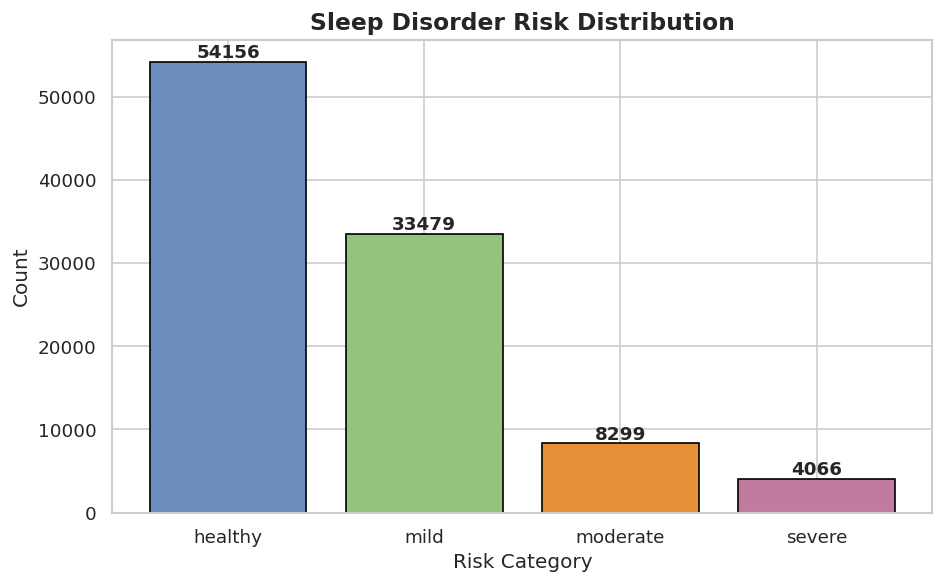

In [150]:
# Target Distribution (Bar Chart)
counts = df["sleep_disorder_risk"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(
    counts.index,
    counts.values,
    color=["#6C8EBF", "#93C47D", "#E69138", "#C27BA0"][:len(counts)],
    edgecolor="black",
    linewidth=1
)

plt.title("Sleep Disorder Risk Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Risk Category")
plt.ylabel("Count")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{height}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

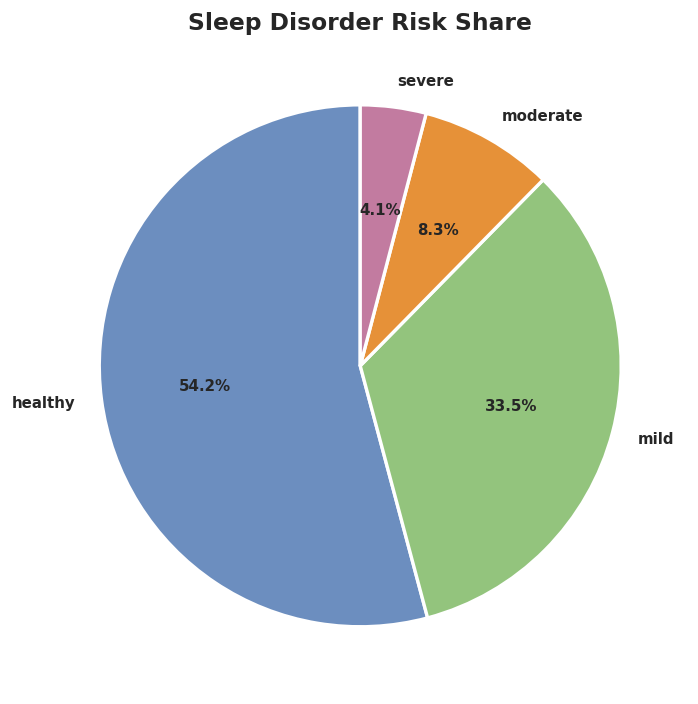

In [152]:
# Target Distribution (Pie Chart)
counts = df["sleep_disorder_risk"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#6C8EBF", "#93C47D", "#E69138", "#C27BA0"][:len(counts)],
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 9, "fontweight": "bold"}
)

plt.title("Sleep Disorder Risk Share", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

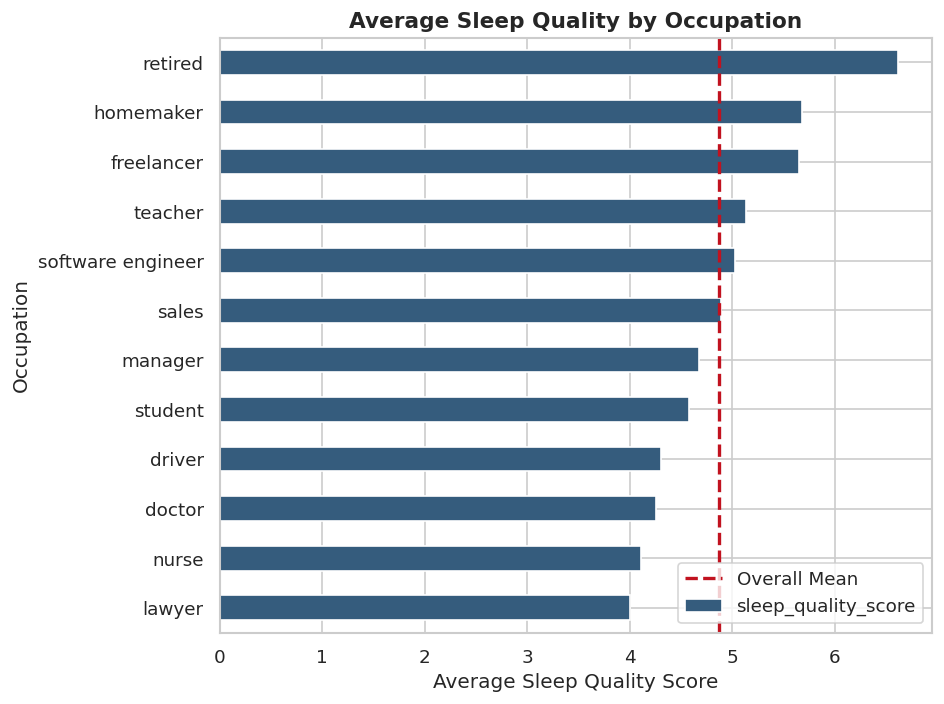

In [133]:
# Average sleep quality score by occupation
occ_quality = df.groupby("occupation")["sleep_quality_score"].mean().sort_values()

plt.figure(figsize=(8, 6))
occ_quality.plot(kind="barh", color="#355c7d", edgecolor="white")

plt.axvline(
    df["sleep_quality_score"].mean(),
    color="#c1121f",
    linestyle="--",
    linewidth=2,
    label="Overall Mean"
)

plt.title("Average Sleep Quality by Occupation", fontsize=13, fontweight="bold")
plt.xlabel("Average Sleep Quality Score")
plt.ylabel("Occupation")
plt.legend()
plt.tight_layout()
plt.show()

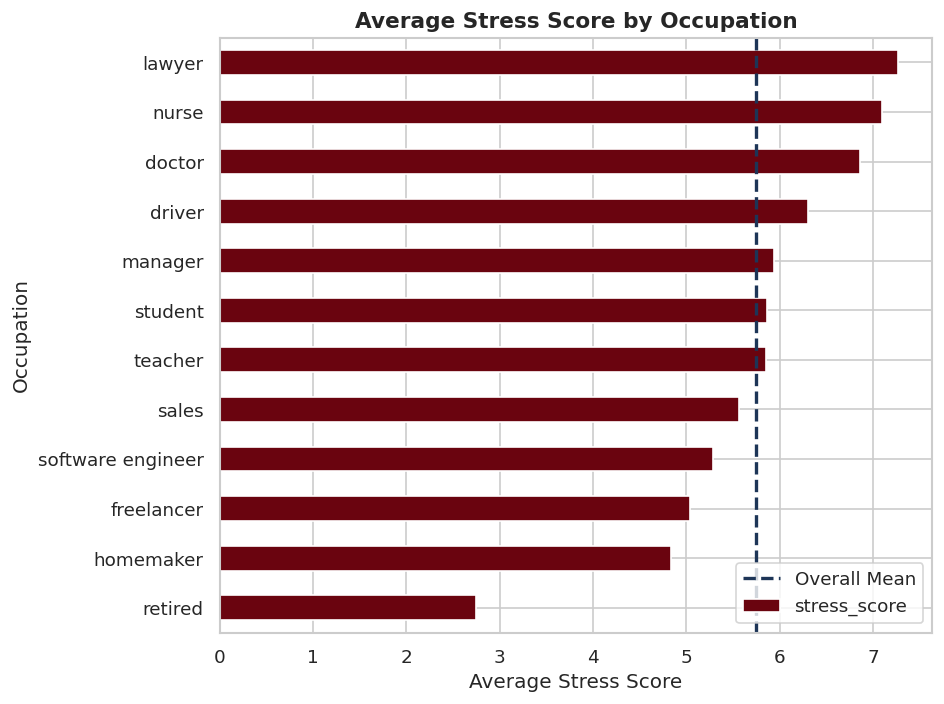

In [134]:
# Average stress score by occupation
occ_stress = df.groupby("occupation")["stress_score"].mean().sort_values()

plt.figure(figsize=(8, 6))
occ_stress.plot(kind="barh", color="#6a040f", edgecolor="white")

plt.axvline(
    df["stress_score"].mean(),
    color="#1d3557",
    linestyle="--",
    linewidth=2,
    label="Overall Mean"
)

plt.title("Average Stress Score by Occupation", fontsize=13, fontweight="bold")
plt.xlabel("Average Stress Score")
plt.ylabel("Occupation")
plt.legend()
plt.tight_layout()
plt.show()

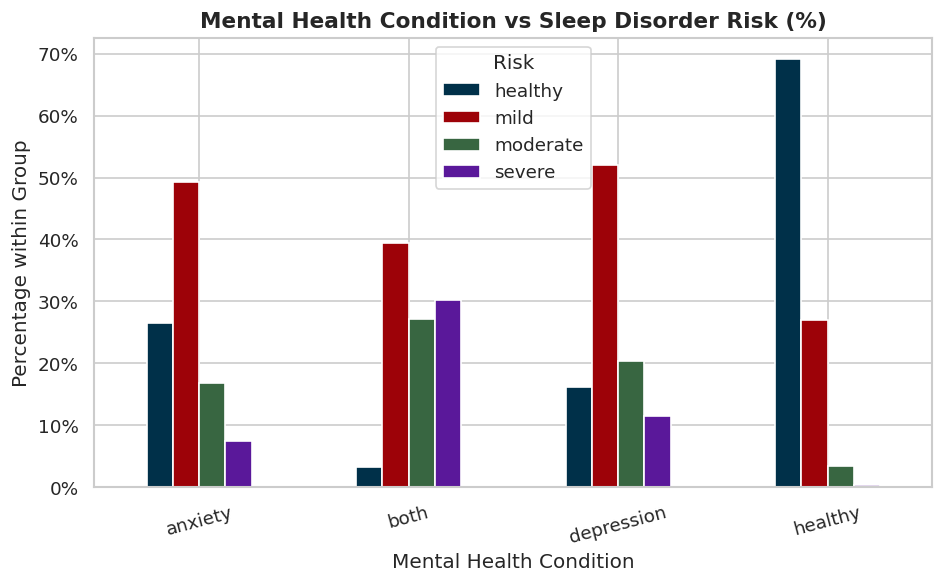

In [135]:
# Normalized bar chart for mental health condition vs risk
ct = pd.crosstab(df["mental_health_condition"], df["sleep_disorder_risk"], normalize="index") * 100

ax = ct.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="white",
    color=["#003049", "#9d0208", "#386641", "#5a189a"][:ct.shape[1]]
)

plt.title("Mental Health Condition vs Sleep Disorder Risk (%)", fontsize=13, fontweight="bold")
plt.xlabel("Mental Health Condition")
plt.ylabel("Percentage within Group")
plt.xticks(rotation=15)
plt.legend(title="Risk")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

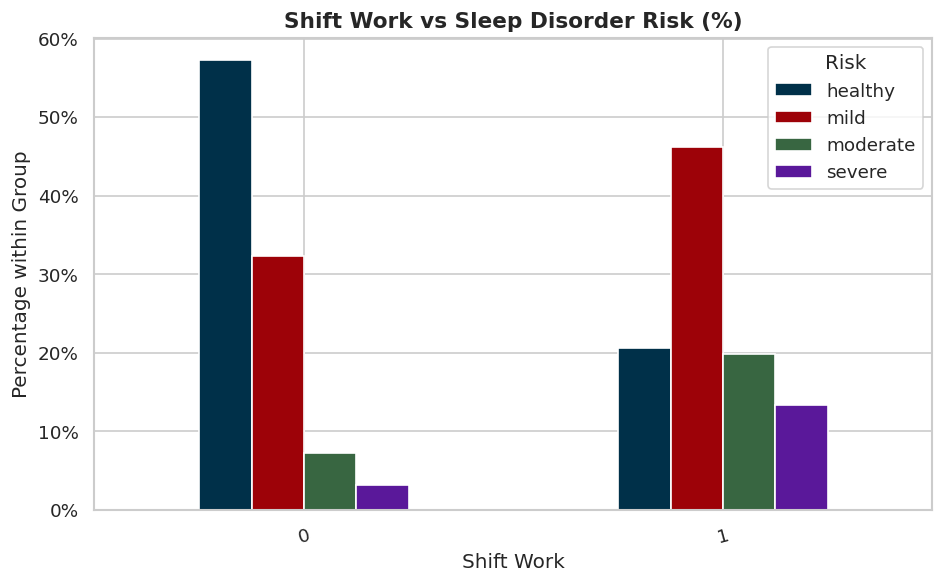

In [136]:
# Normalized bar chart for shift work vs risk
ct = pd.crosstab(df["shift_work"], df["sleep_disorder_risk"], normalize="index") * 100

ax = ct.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="white",
    color=["#003049", "#9d0208", "#386641", "#5a189a"][:ct.shape[1]]
)

plt.title("Shift Work vs Sleep Disorder Risk (%)", fontsize=13, fontweight="bold")
plt.xlabel("Shift Work")
plt.ylabel("Percentage within Group")
plt.xticks(rotation=15)
plt.legend(title="Risk")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

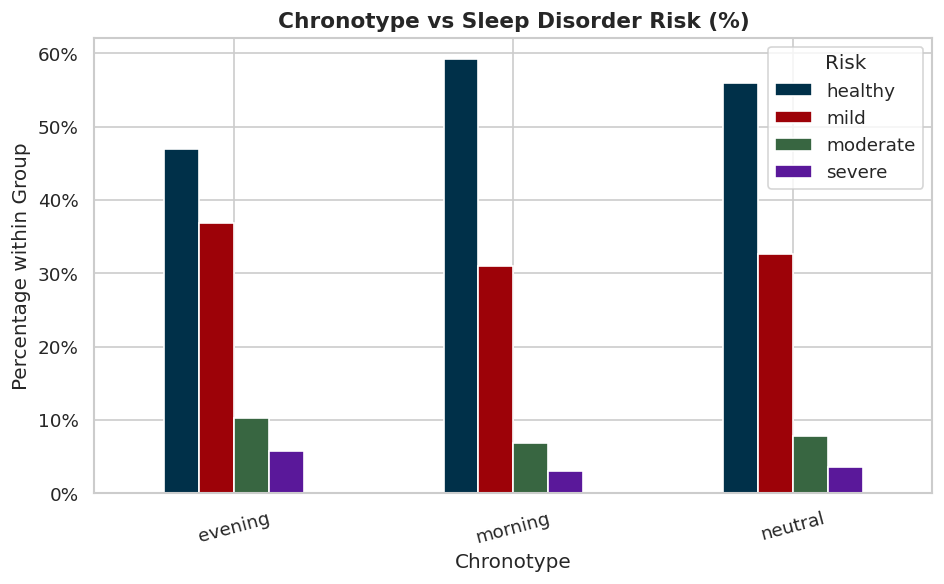

In [137]:
# Normalized bar chart for chronotype vs risk
ct = pd.crosstab(df["chronotype"], df["sleep_disorder_risk"], normalize="index") * 100

ax = ct.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="white",
    color=["#003049", "#9d0208", "#386641", "#5a189a"][:ct.shape[1]]
)

plt.title("Chronotype vs Sleep Disorder Risk (%)", fontsize=13, fontweight="bold")
plt.xlabel("Chronotype")
plt.ylabel("Percentage within Group")
plt.xticks(rotation=15)
plt.legend(title="Risk")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

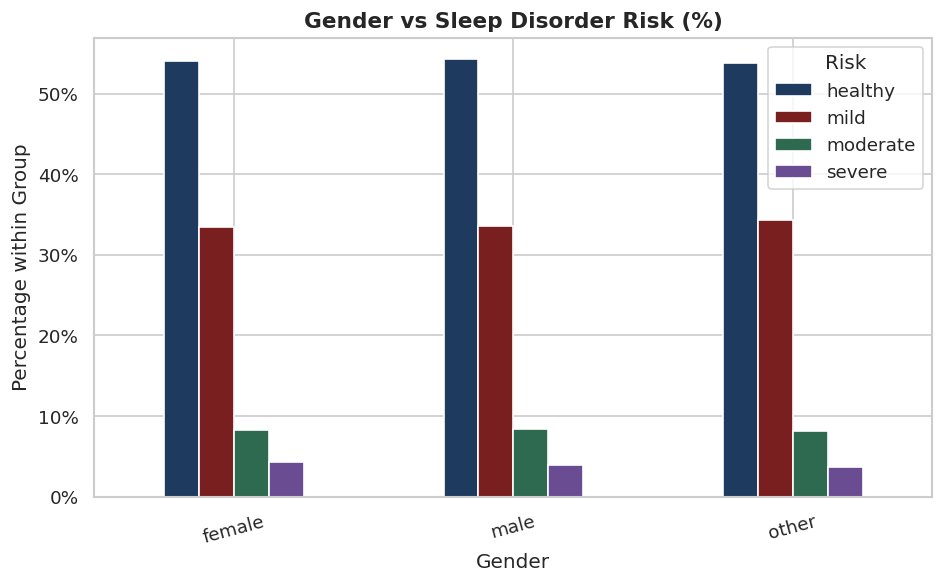

In [138]:
# Normalized bar chart for gender vs risk
ct = pd.crosstab(df["gender"], df["sleep_disorder_risk"], normalize="index") * 100

ax = ct.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="white",
    color=["#1f3a5f", "#7a1f1f", "#2d6a4f", "#6a4c93"][:ct.shape[1]]
)

plt.title("Gender vs Sleep Disorder Risk (%)", fontsize=13, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Percentage within Group")
plt.xticks(rotation=15)
plt.legend(title="Risk")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

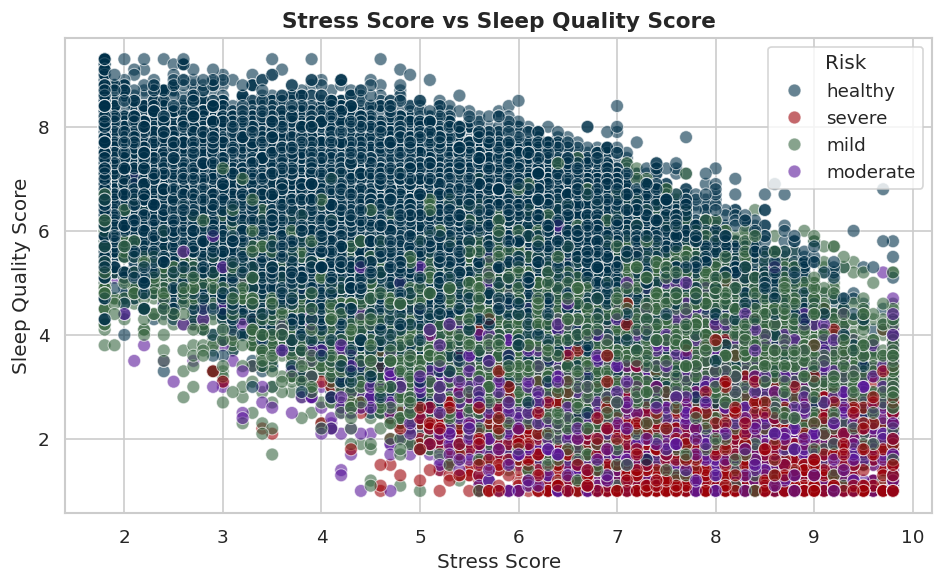

In [153]:
# Scatter plot for stress score vs sleep quality score
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="stress_score",
    y="sleep_quality_score",
    hue="sleep_disorder_risk",
    palette=["#003049", "#9d0208", "#386641", "#5a189a"],
    alpha=0.6,
    s=60
)

plt.title("Stress Score vs Sleep Quality Score", fontsize=13, fontweight="bold")
plt.xlabel("Stress Score")
plt.ylabel("Sleep Quality Score")
plt.legend(title="Risk")
plt.tight_layout()
plt.show()

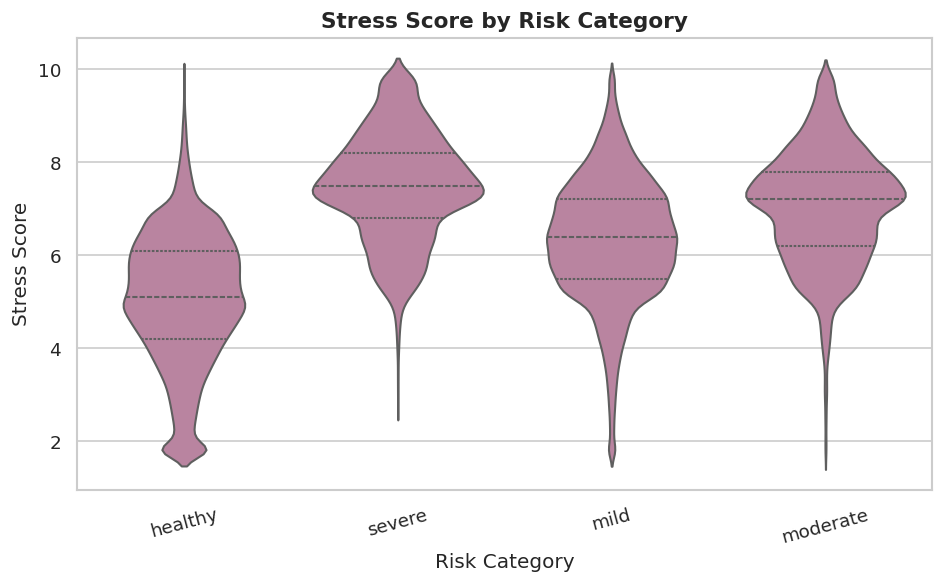

In [141]:
# Violin plot for stress score by risk category
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="sleep_disorder_risk",
    y="stress_score",
    color="#C27BA0",
    inner="quartile"
)

plt.title("Stress Score by Risk Category", fontsize=13, fontweight="bold")
plt.xlabel("Risk Category")
plt.ylabel("Stress Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

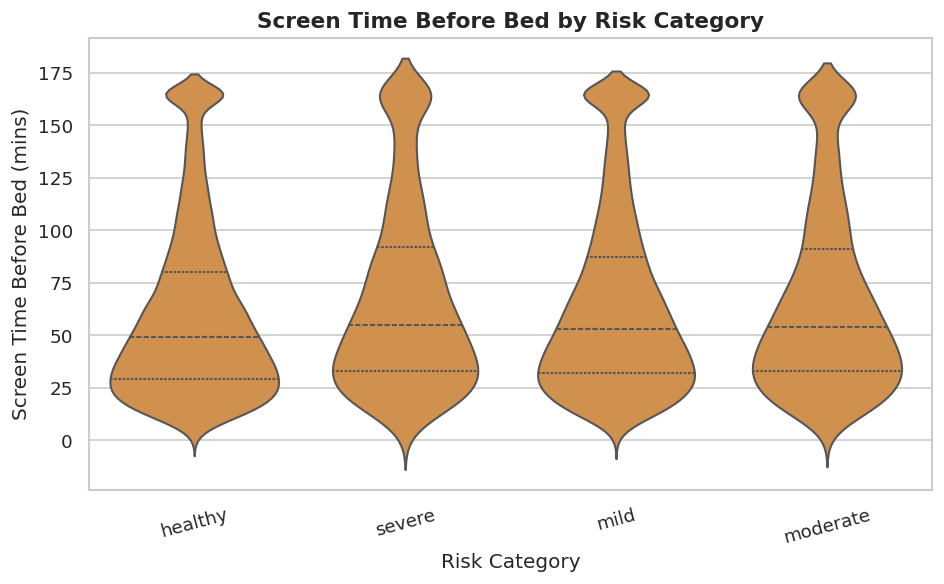

In [142]:
# Violin plot for screen time before bed by risk category
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="sleep_disorder_risk",
    y="screen_time_before_bed_mins",
    color="#E69138",
    inner="quartile"
)

plt.title("Screen Time Before Bed by Risk Category", fontsize=13, fontweight="bold")
plt.xlabel("Risk Category")
plt.ylabel("Screen Time Before Bed (mins)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

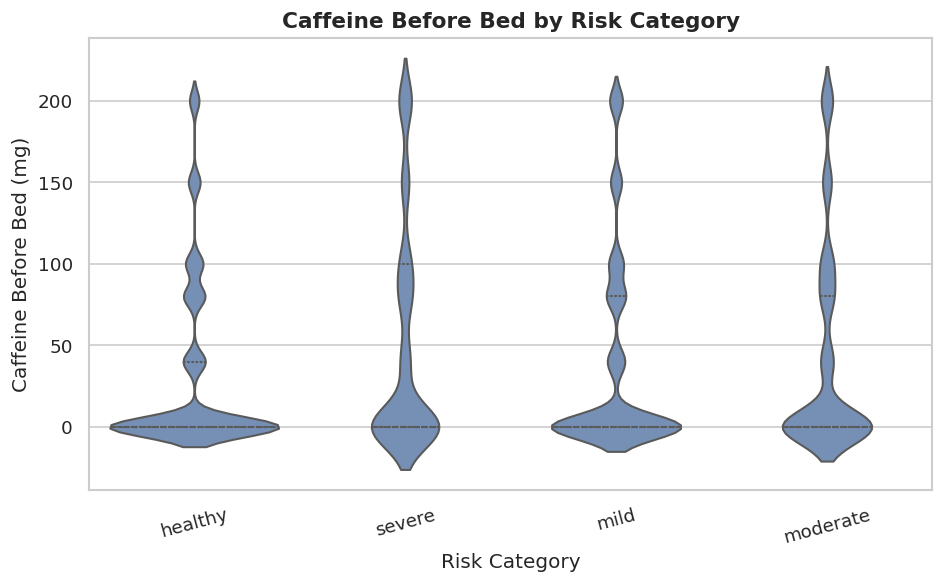

In [143]:
# Violin plot for caffeine intake before bed by risk category
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="sleep_disorder_risk",
    y="caffeine_mg_before_bed",
    color="#6C8EBF",
    inner="quartile"
)

plt.title("Caffeine Before Bed by Risk Category", fontsize=13, fontweight="bold")
plt.xlabel("Risk Category")
plt.ylabel("Caffeine Before Bed (mg)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

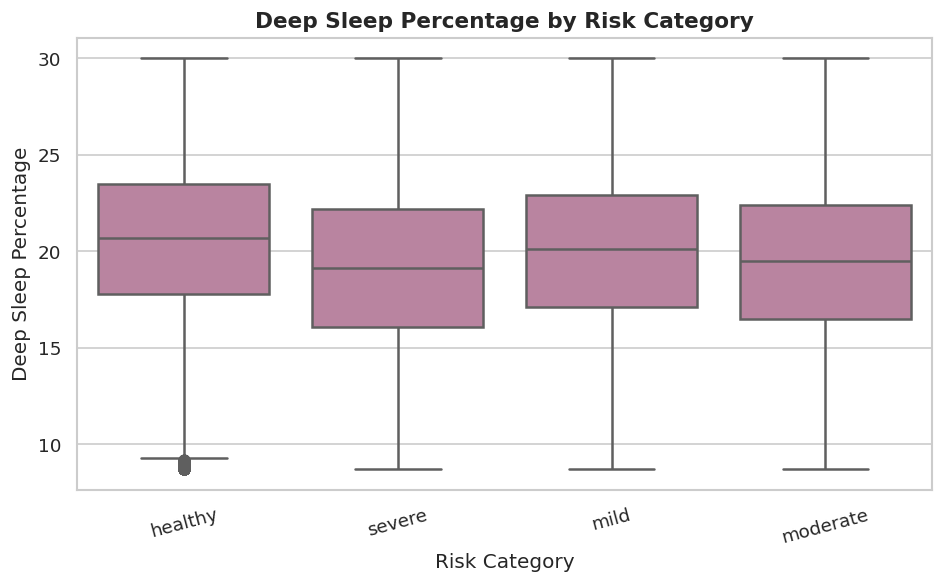

In [144]:
# Box plot for deep sleep percentage by risk category
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="sleep_disorder_risk",
    y="deep_sleep_percentage",
    color="#C27BA0",
    linewidth=1.5
)

plt.title("Deep Sleep Percentage by Risk Category", fontsize=13, fontweight="bold")
plt.xlabel("Risk Category")
plt.ylabel("Deep Sleep Percentage")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

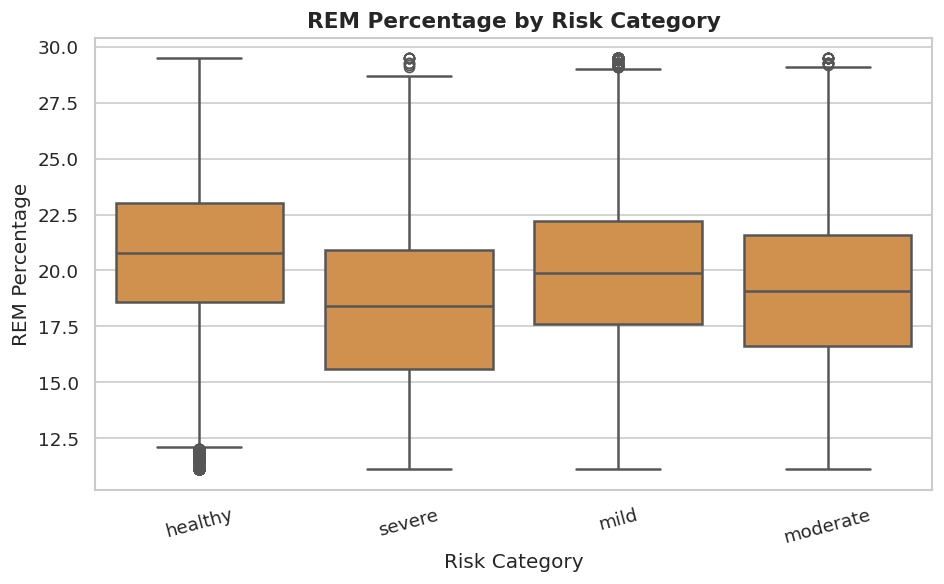

In [145]:
# Box plot for REM percentage by risk category
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="sleep_disorder_risk",
    y="rem_percentage",
    color="#E69138",
    linewidth=1.5
)

plt.title("REM Percentage by Risk Category", fontsize=13, fontweight="bold")
plt.xlabel("Risk Category")
plt.ylabel("REM Percentage")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

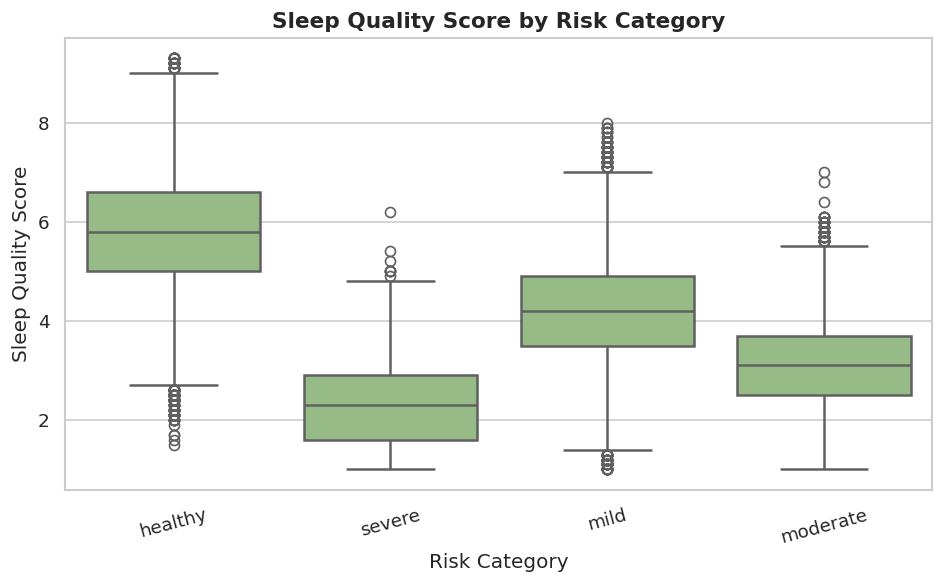

In [146]:
# Box plot for sleep quality score by risk category
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="sleep_disorder_risk",
    y="sleep_quality_score",
    color="#93C47D",
    linewidth=1.5
)

plt.title("Sleep Quality Score by Risk Category", fontsize=13, fontweight="bold")
plt.xlabel("Risk Category")
plt.ylabel("Sleep Quality Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

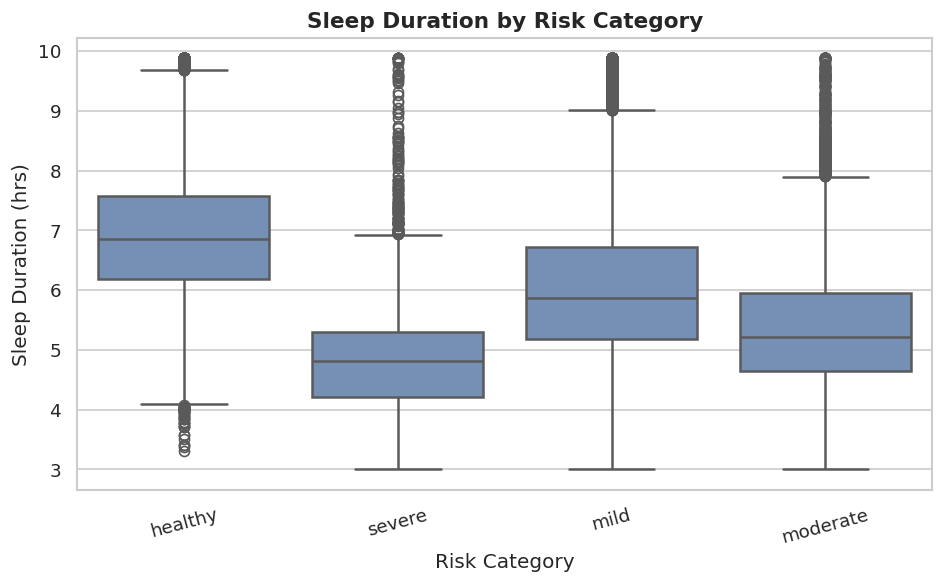

In [147]:
# Box plot for sleep duration by risk category
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="sleep_disorder_risk",
    y="sleep_duration_hrs",
    color="#6C8EBF",
    linewidth=1.5
)

plt.title("Sleep Duration by Risk Category", fontsize=13, fontweight="bold")
plt.xlabel("Risk Category")
plt.ylabel("Sleep Duration (hrs)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

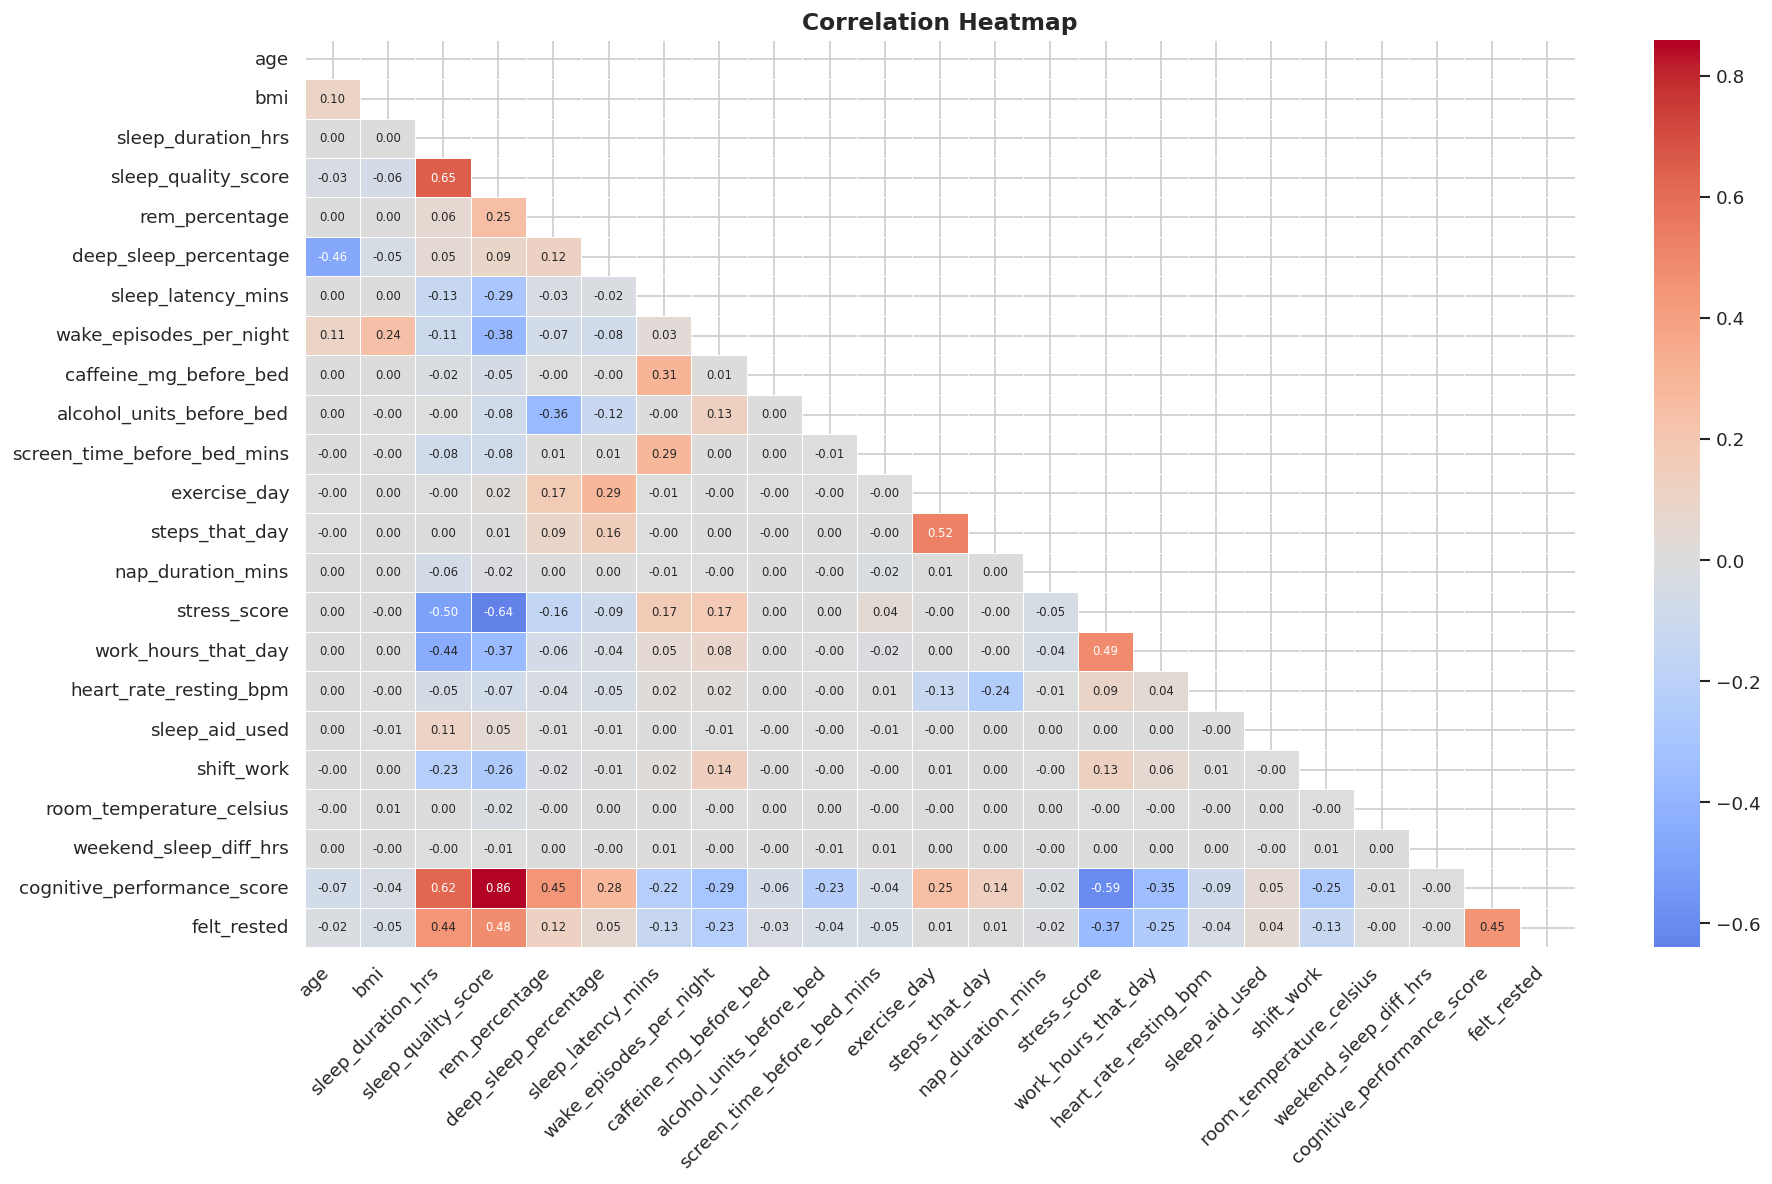

In [140]:
# Correlation heatmap
corr = df.select_dtypes(include="number").corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 10))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 7}
)

plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()